# LocaleLive — Lambda Log Analysis

This notebook pulls real execution logs from the `localelive-backend` AWS Lambda function and derives insights useful for anomaly-detection evaluation.

**Log group:** `/aws/lambda/localelive-backend`  
**Region:** `us-east-1`

### What you get
- Per-request latency distribution (p50 / p95 / p99)
- Routing breakdown (which agent path handled each query)
- Error & empty-result rates over time
- Single-request trace by `rid`
- Anomaly flags: requests that are outliers in latency or have unexpected routing

---
### Setup
```bash
pip install boto3 pandas matplotlib seaborn python-dotenv
```
Place `credentials.env` in the same directory as this notebook (it is gitignored).

In [27]:
pip install boto3 pandas matplotlib seaborn python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [28]:
import os
import re
import json
import time
from datetime import datetime, timezone, timedelta
from pathlib import Path

import boto3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from dotenv import load_dotenv

# Load credentials from credentials.env (never committed)
creds_path = Path("credentials.env")
if not creds_path.exists():
    raise FileNotFoundError(
        "credentials.env not found. Create it from the template — see README."
    )
load_dotenv(creds_path)

AWS_ACCESS_KEY_ID     = os.environ["AWS_ACCESS_KEY_ID"]
AWS_SECRET_ACCESS_KEY = os.environ["AWS_SECRET_ACCESS_KEY"]
AWS_DEFAULT_REGION    = os.environ.get("AWS_DEFAULT_REGION", "us-east-1")
LOG_GROUP_NAME        = os.environ.get("LOG_GROUP_NAME", "/aws/lambda/localelive-backend")

logs_client = boto3.client(
    "logs",
    aws_access_key_id=AWS_ACCESS_KEY_ID,
    aws_secret_access_key=AWS_SECRET_ACCESS_KEY,
    region_name=AWS_DEFAULT_REGION,
)

print(f"Connected — log group: {LOG_GROUP_NAME}")

Connected — log group: /aws/lambda/localelive-backend


In [29]:
# ── Time window ──────────────────────────────────────────────────────────────
# Change LOOKBACK_HOURS to widen or narrow the analysis window.
LOOKBACK_HOURS = 72

now_ms   = int(time.time() * 1000)
start_ms = now_ms - LOOKBACK_HOURS * 3600 * 1000

print(f"Window: last {LOOKBACK_HOURS}h  "
      f"({datetime.fromtimestamp(start_ms/1000, tz=timezone.utc).strftime('%Y-%m-%d %H:%M UTC')} "
      f"→ now)")

Window: last 72h  (2026-07-09 20:31 UTC → now)


In [30]:
def run_insights_query(query_string: str, start_ms: int, end_ms: int,
                        limit: int = 10_000) -> list[dict]:
    """Run a CloudWatch Insights query and return all result rows as dicts."""
    resp = logs_client.start_query(
        logGroupName=LOG_GROUP_NAME,
        startTime=start_ms // 1000,
        endTime=end_ms // 1000,
        queryString=query_string,
        limit=limit,
    )
    query_id = resp["queryId"]

    while True:
        result = logs_client.get_query_results(queryId=query_id)
        status = result["status"]
        if status in ("Complete", "Failed", "Cancelled", "Timeout"):
            break
        time.sleep(1)

    if status != "Complete":
        raise RuntimeError(f"CloudWatch Insights query ended with status: {status}")

    rows = []
    for row in result["results"]:
        rows.append({field["field"]: field["value"] for field in row})
    return rows


def filter_log_events(pattern: str, start_ms: int, end_ms: int,
                       max_events: int = 5000) -> list[dict]:
    """Pull raw log events matching a filter pattern."""
    events = []
    kwargs = dict(
        logGroupName=LOG_GROUP_NAME,
        startTime=start_ms,
        endTime=end_ms,
        filterPattern=pattern,
        limit=100,
    )
    while len(events) < max_events:
        resp = logs_client.filter_log_events(**kwargs)
        events.extend(resp.get("events", []))
        token = resp.get("nextToken")
        if not token:
            break
        kwargs["nextToken"] = token
    return events

print("Helper functions defined.")

Helper functions defined.


## 1 — Pull `query_complete` events

Each completed request emits one structured log line:
```
query_complete rid=<uuid> user=<id> duration=4.87s path=['GoogleMaps'] results=3
```

In [31]:
raw_complete = filter_log_events('"query_complete"', start_ms, now_ms)
print(f"Found {len(raw_complete)} query_complete events")

_re = re.compile(
    r"query_complete"
    r" rid=(?P<rid>[\w-]+)"
    r" user=(?P<user>\S+)"
    r" duration=(?P<duration>[\d.]+)s"
    r" path=(?P<path>\[.*?\])"
    r" results=(?P<results>\d+)"
)

records = []
for ev in raw_complete:
    m = _re.search(ev["message"])
    if not m:
        continue
    records.append({
        "timestamp": datetime.fromtimestamp(ev["timestamp"] / 1000, tz=timezone.utc),
        "rid":       m.group("rid"),
        "user":      m.group("user"),
        "duration":  float(m.group("duration")),
        "path":      m.group("path"),
        "results":   int(m.group("results")),
    })

df = pd.DataFrame(records)
if df.empty:
    print("No parsed records — check the lookback window or confirm logs exist.")
else:
    # Derive primary agent from path string
    def _primary_agent(path_str: str) -> str:
        if "IoT_engine" in path_str:   return "IoT_engine"
        if "GoogleMaps" in path_str:   return "GoogleMaps"
        if "scrapper"   in path_str:   return "scrapper"
        return "direct_answer"

    df["agent"] = df["path"].apply(_primary_agent)
    df["zero_results"] = df["results"] == 0
    print(df.dtypes)
    df.tail(5)

Found 1 query_complete events
timestamp       datetime64[us, UTC]
rid                             str
user                            str
duration                    float64
path                            str
results                       int64
agent                           str
zero_results                   bool
dtype: object


## 2 — Latency distribution

p50=2.06s  p95=2.06s  p99=2.06s  n=1


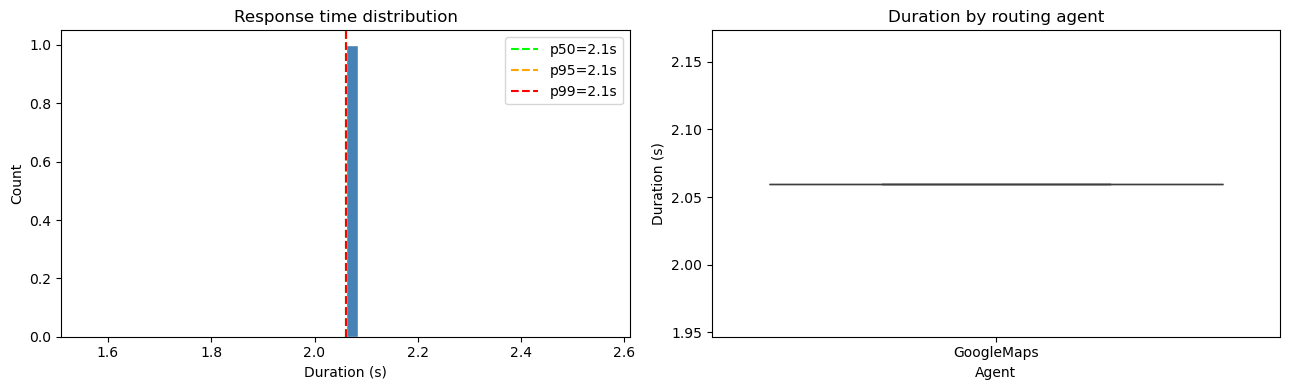

In [32]:
if not df.empty:
    p50 = df["duration"].quantile(0.50)
    p95 = df["duration"].quantile(0.95)
    p99 = df["duration"].quantile(0.99)
    print(f"p50={p50:.2f}s  p95={p95:.2f}s  p99={p99:.2f}s  n={len(df)}")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Histogram
    axes[0].hist(df["duration"], bins=40, color="steelblue", edgecolor="white")
    for pct, val, color in [("p50", p50, "lime"), ("p95", p95, "orange"), ("p99", p99, "red")]:
        axes[0].axvline(val, color=color, linestyle="--", linewidth=1.5, label=f"{pct}={val:.1f}s")
    axes[0].set_xlabel("Duration (s)")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Response time distribution")
    axes[0].legend()

    # Box plot by agent — use seaborn which supports the order parameter
    agent_order = df.groupby("agent")["duration"].median().sort_values().index.tolist()
    sns.boxplot(data=df, x="agent", y="duration", order=agent_order, ax=axes[1])
    axes[1].set_title("Duration by routing agent")
    axes[1].set_xlabel("Agent")
    axes[1].set_ylabel("Duration (s)")
    plt.tight_layout()
    plt.show()

## 3 — Routing breakdown

            count    pct
agent                   
GoogleMaps      1  100.0


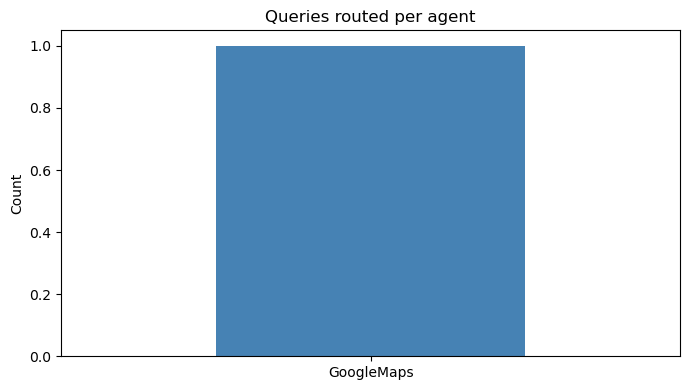

In [33]:
if not df.empty:
    counts = df["agent"].value_counts()
    pcts   = (counts / len(df) * 100).round(1)
    print(pd.DataFrame({"count": counts, "pct": pcts}))

    fig, ax = plt.subplots(figsize=(7, 4))
    counts.plot(kind="bar", ax=ax, color=["steelblue", "seagreen", "coral", "mediumpurple"][:len(counts)])
    ax.set_title("Queries routed per agent")
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.show()

## 4 — Error & zero-result rate over time

In [34]:
# Pull ERROR-level log lines separately
raw_errors = filter_log_events('"ERROR"', start_ms, now_ms)
print(f"Raw ERROR events: {len(raw_errors)}")

error_ts = [
    datetime.fromtimestamp(ev["timestamp"] / 1000, tz=timezone.utc)
    for ev in raw_errors
]
df_errors = pd.DataFrame({"timestamp": error_ts, "type": "error"})

if not df.empty:
    df_zero = df[df["zero_results"]][["timestamp"]].copy()
    df_zero["type"] = "zero_results"

    combined = pd.concat([df_errors, df_zero], ignore_index=True)
    if not combined.empty:
        combined = combined.set_index("timestamp").sort_index()
        resampled = combined.groupby([pd.Grouper(freq="1h"), "type"]).size().unstack(fill_value=0)

        fig, ax = plt.subplots(figsize=(13, 4))
        resampled.plot(kind="bar", ax=ax, width=0.8,
                       color={"error": "crimson", "zero_results": "orange"})
        ax.set_title("Errors and zero-result responses per hour")
        ax.set_xlabel("Hour (UTC)")
        ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print("No errors or zero-result events in window — great!")

Raw ERROR events: 0
No errors or zero-result events in window — great!


## 5 — Latency over time (rolling p95)

Spot degradations or cold-start clusters.

In [ ]:
if not df.empty and len(df) >= 5:
    ts_df = df.assign(timestamp=lambda d: d["timestamp"].dt.tz_localize(None)).set_index("timestamp").sort_index()
    hourly = ts_df["duration"].resample("1h").agg(["median", lambda x: x.quantile(0.95)])
    hourly.columns = ["p50", "p95"]

    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(hourly.index, hourly["p50"], label="p50", color="steelblue")
    ax.fill_between(hourly.index, hourly["p50"], hourly["p95"],
                    alpha=0.25, color="steelblue", label="p50–p95 band")
    ax.plot(hourly.index, hourly["p95"], label="p95", color="orange", linestyle="--")
    ax.set_title("Response latency over time (hourly)")
    ax.set_xlabel("UTC")
    ax.set_ylabel("Duration (s)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %Hh"))
    ax.legend()
    plt.tight_layout()
    plt.show()

## 6 — Anomaly detection: latency outliers

Flag requests whose duration is more than 3 σ above the mean for their agent.

Latency outliers (z > 3): 0 of 1 requests


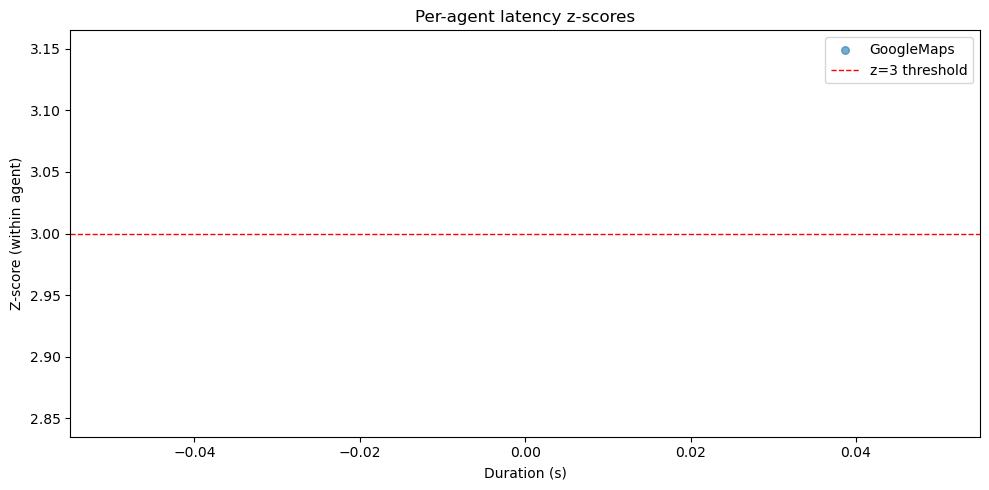

In [36]:
if not df.empty:
    stats = df.groupby("agent")["duration"].agg(["mean", "std"]).rename(
        columns={"mean": "agent_mean", "std": "agent_std"}
    )
    df2 = df.join(stats, on="agent")
    df2["z_score"] = (df2["duration"] - df2["agent_mean"]) / df2["agent_std"].clip(lower=0.01)
    outliers = df2[df2["z_score"] > 3].sort_values("z_score", ascending=False)

    print(f"Latency outliers (z > 3): {len(outliers)} of {len(df)} requests")
    if not outliers.empty:
        display(outliers[["timestamp", "rid", "agent", "duration", "z_score", "results"]].head(20))

    # Scatter: duration vs z-score, coloured by agent
    fig, ax = plt.subplots(figsize=(10, 5))
    for agent, grp in df2.groupby("agent"):
        ax.scatter(grp["duration"], grp["z_score"], label=agent, alpha=0.6, s=30)
    ax.axhline(3, color="red", linestyle="--", linewidth=1, label="z=3 threshold")
    ax.set_xlabel("Duration (s)")
    ax.set_ylabel("Z-score (within agent)")
    ax.set_title("Per-agent latency z-scores")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 7 — Anomaly detection: unexpected routing

Queries that hit a fallback chain (e.g. IoT → GoogleMaps → scrapper) indicate the system couldn't answer with its primary data source.

Multi-hop fallback requests: 0 (0.0%)


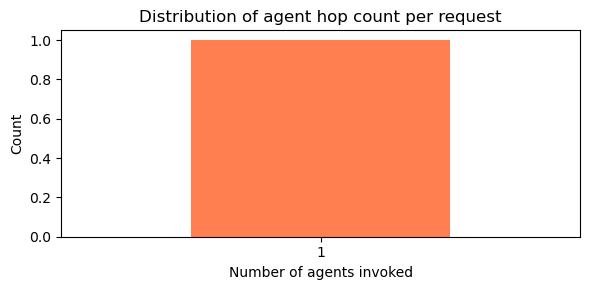

In [37]:
if not df.empty:
    # Multi-hop: path string contains more than one agent name
    agent_names = ["IoT_engine", "GoogleMaps", "scrapper"]
    df["hop_count"] = df["path"].apply(
        lambda p: sum(1 for a in agent_names if a in p)
    )
    multihop = df[df["hop_count"] > 1].sort_values("timestamp")
    print(f"Multi-hop fallback requests: {len(multihop)} ({len(multihop)/len(df)*100:.1f}%)")

    hop_dist = df["hop_count"].value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(6, 3))
    hop_dist.plot(kind="bar", ax=ax, color="coral")
    ax.set_title("Distribution of agent hop count per request")
    ax.set_xlabel("Number of agents invoked")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.show()

    if not multihop.empty:
        display(multihop[["timestamp", "rid", "path", "duration", "results"]].head(10))

## 8 — Trace a single request end-to-end

Paste any `rid` from the table above to see every log line for that request in order.

In [38]:
# Set to any rid from the dataframe above
TRACE_RID = ""  # e.g. "f3a2b1c4-..."

if TRACE_RID:
    events = filter_log_events(f'"rid={TRACE_RID}"', start_ms, now_ms)
    if not events:
        print(f"No events found for rid={TRACE_RID}")
    else:
        print(f"{'Time (UTC)':<28}  {'Message'}")
        print("-" * 100)
        for ev in sorted(events, key=lambda e: e["timestamp"]):
            ts = datetime.fromtimestamp(ev["timestamp"] / 1000, tz=timezone.utc).strftime("%Y-%m-%d %H:%M:%S.%f")[:-3]
            # Strip Lambda boilerplate prefix
            msg = re.sub(r"^.*?INFO\s+|^.*?WARNING\s+|^.*?ERROR\s+", "", ev["message"].strip())
            print(f"{ts}  {msg}")
else:
    if not df.empty:
        # Auto-pick the slowest request as a default example
        example_rid = df.loc[df["duration"].idxmax(), "rid"]
        print(f"Set TRACE_RID to a rid from the table above, e.g.: '{example_rid}'")
    else:
        print("Set TRACE_RID to a correlation ID from the logs.")

Set TRACE_RID to a rid from the table above, e.g.: 'a9dc8ec5-9f31-403d-a87d-d71d797a3078'


## 9 — Summary statistics export

Saves a clean CSV ready for use in a paper or further analysis.

In [39]:
if not df.empty:
    out_path = Path("localelive_query_log.csv")
    # Drop user field before export — anonymise
    export_cols = ["timestamp", "rid", "duration", "agent", "path", "results", "zero_results", "hop_count"]
    export_cols = [c for c in export_cols if c in df.columns]
    df[export_cols].to_csv(out_path, index=False)
    print(f"Exported {len(df)} rows to {out_path}")

    summary = {
        "window_hours":      LOOKBACK_HOURS,
        "total_requests":    len(df),
        "p50_latency_s":     round(df["duration"].quantile(0.50), 3),
        "p95_latency_s":     round(df["duration"].quantile(0.95), 3),
        "p99_latency_s":     round(df["duration"].quantile(0.99), 3),
        "zero_result_rate":  round(df["zero_results"].mean(), 4),
        "routing_breakdown": df["agent"].value_counts().to_dict(),
    }
    print(json.dumps(summary, indent=2))

Exported 1 rows to localelive_query_log.csv
{
  "window_hours": 72,
  "total_requests": 1,
  "p50_latency_s": 2.06,
  "p95_latency_s": 2.06,
  "p99_latency_s": 2.06,
  "zero_result_rate": 0.0,
  "routing_breakdown": {
    "GoogleMaps": 1
  }
}
